# Multi-Branch Keras — Modality-Specific Sequence Classifier

This notebook uses a multi-branch deep learning architecture where each sensor modality (Acceleration, Rotation, TOF, Thermopile, STFT, CWT) has its own dedicated branch. 

It follows the exact style of the Random Forest notebook:
- configuration
- data loading
- split
- estimator (Keras Multi-Branch)
- parameter search (grid or Bayesian)
- holdout evaluation
- save results

In [1]:
import os
import sys
import warnings
import json
import importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Local path routing
current_dir = os.getcwd()
workspace_root = current_dir
if os.path.basename(current_dir) == 'notebooks':
    workspace_root = os.path.dirname(current_dir)

src_path = os.path.join(workspace_root, 'src')
sys.path.insert(0, workspace_root)
sys.path.insert(0, src_path)

# Robust Kaggle path routing (handles nested folders from zip uploads)
if os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        # If we find our custom modules in this directory, add it to sys.path
        if 'data_utils.py' in files or 'base_utils_qwen.py' in files or 'multibranch_attention.py' in files:
            if root not in sys.path:
                sys.path.insert(0, root)

from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline

try:
    import skopt
    from skopt import BayesSearchCV
    from skopt.space import Categorical, Integer, Real
    SKOPT_AVAILABLE = True
except ImportError:
    BayesSearchCV = None
    Categorical = Integer = Real = None
    SKOPT_AVAILABLE = False

import data_utils
import multibranch_attention as multibranch_keras
importlib.reload(multibranch_keras)
from base_utils_qwen import (
    SequenceExtractor,
    SensorAugmentor,
    evaluate_holdout,
    prepare_bayesian_space
)
import matplotlib.pyplot as plt
from pathlib import Path

print('Imports loaded successfully')

Imports loaded successfully


In [2]:
experiment_name = 'multibranch_attention'

# Supported targets: 'bfrb', 'gesture_action', 'orientation', 'gesture', 'gesture_position'
TARGET_COL = 'bfrb'

# Use sample.csv for a quick smoke test; set False for full train.csv
use_sample_data = False
sample_file = 'sample.csv'

search_mode = 'bayesian'  # 'grid' or 'bayesian'
random_state = 42
n_splits = 1              # 1 -> GroupShuffleSplit; >=2 -> GroupKFold

train_size = 0.8
n_iter = 37
verbose = 4
error_score =  np.nan
n_jobs = 1                 # TensorFlow models should not be fitted in parallel

orientation_filter_list = [] # 'Seated Lean Non Dom - FACE DOWN', 'Lie on Side - Non Dominant', 'Seated Straight', 'Lie on Back'
gesture_position_filter_list = [] # 'Neck', 'Above ear', 'Cheek', 'Eyelash', 'Eyebrow', 'Forehead'
gesture_filter_list = [] # 'Cheek - pinch skin', 'Eyelash - pull hair', 'Eyebrow - pull hair', 'Forehead - scratch', 'Forehead - pull hairline'

problematic_sequence_bool = True

target_only_bool = True

results_dir = Path(workspace_root) / f'results_{experiment_name}_{TARGET_COL}_{search_mode}'
results_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

search_mode = str(search_mode).lower()
if search_mode in ('bayes', 'bayesian'):
    search_mode = 'bayesian'
elif search_mode != 'grid':
    raise ValueError("search_mode must be 'grid' or 'bayesian'")

if n_splits <= 1:
    cv_object = GroupShuffleSplit(
        n_splits=1,
        test_size=(1 - train_size),
        random_state=random_state,
    )
else:
    cv_object = GroupKFold(n_splits=n_splits)

In [3]:
data_root = data_utils.find_data_root()
sample_path = data_root / sample_file

if use_sample_data and sample_path.exists():
    raw_train_df = pd.read_csv(sample_path)
    print(f'Using {sample_file}: {raw_train_df["sequence_id"].nunique()} sequences')
else:
    raw_train_df = pd.read_csv(data_root / 'train.csv')
    print(f'Using train.csv: {raw_train_df["sequence_id"].nunique()} sequences')

train_demo_path = data_root / 'train_demographics.csv'
train_demo_df = pd.read_csv(train_demo_path) if train_demo_path.exists() else None

# Derive all supported sequence targets using the same definitions as random_forest.ipynb.
train_df = raw_train_df.copy()
train_df['gesture'] = train_df['gesture'].fillna('non_bfrb').astype(str)
train_df['orientation'] = train_df['orientation'].fillna('Unknown').astype(str)
train_df['is_target'] = train_df['sequence_type'].eq('Target').astype(int)
train_df['bfrb'] = train_df['gesture'].where(train_df['is_target'].astype(bool), 'non_bfrb')
train_df['gesture_position'] = train_df['gesture'].str.split(' - ').str[0]
train_df['gesture_action'] = train_df['gesture'].str.split(' - ').str[-1]

if TARGET_COL not in {'bfrb', 'gesture_action', 'orientation', 'gesture', 'gesture_position'}:
    raise ValueError("TARGET_COL must be one of 'bfrb', 'gesture_action', 'orientation', or 'gesture'.")

if orientation_filter_list:
    train_df = train_df[train_df['orientation'].isin(orientation_filter_list)].copy()

if gesture_position_filter_list:
    train_df = train_df[train_df['gesture_position'].isin(gesture_position_filter_list)].copy()

if gesture_filter_list:
    train_df = train_df[train_df['gesture'].isin(gesture_filter_list)].copy()

if target_only_bool:
    train_df = train_df[train_df['is_target'] == 1].copy()

train_df[TARGET_COL] = train_df[TARGET_COL].fillna('non_bfrb').astype(str)
print(f'Target: {TARGET_COL}; sequences after filters: {train_df["sequence_id"].nunique()}')

Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
Using train.csv: 8151 sequences
Target: bfrb; sequences after filters: 5113


In [4]:
try:
    train_sample_df, hold_out_df = data_utils.sample_balanced_split(
        train_df,
        train_pct=train_size,
        test_pct=(1 - train_size),
        random_state=random_state,
    )
except Exception as split_error:
    print(f'Balanced split unavailable ({split_error}); using grouped random split.')
    sequence_df = (
        train_df[['sequence_id', 'is_target', TARGET_COL]]
        .drop_duplicates('sequence_id')
        .sort_values('sequence_id')
    )
    splitter = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(sequence_df, groups=sequence_df['sequence_id']))
    train_ids = sequence_df.iloc[train_idx]['sequence_id']
    test_ids = sequence_df.iloc[test_idx]['sequence_id']
    train_sample_df = train_df[train_df['sequence_id'].isin(train_ids)].copy()
    hold_out_df = train_df[train_df['sequence_id'].isin(test_ids)].copy()

X_train = train_sample_df.copy()
X_test = hold_out_df.copy()
y_train = X_train[['sequence_id', 'is_target', TARGET_COL]].copy()
y_test = X_test[['sequence_id', 'is_target', TARGET_COL]].copy()
groups = X_train['sequence_id'].astype(str)

print('Train sequences:', X_train['sequence_id'].nunique())
print('Holdout sequences:', X_test['sequence_id'].nunique())

Train: 3856 seqs | 75.4%
Test:  629 seqs  | 12.3%
Train sequences: 3856
Holdout sequences: 629


In [5]:
extractor = SequenceExtractor(
    output_format='chunks',
    acc_modes='smoothed|velocity|displacement|jerk',
)

clf = multibranch_keras.MultiBranchSequenceClassifier(
    extractor=extractor,
    augmentor=SensorAugmentor(
        sequence_col='sequence_id',
        counter_col='sequence_counter',
        prob=0.0,
        per_aug_prob=0.0,
    ),
    primary_target=TARGET_COL,
    verbose=1,
    random_state=random_state,
)

pipeline = Pipeline([
    ('estimator', clf),
])

In [6]:
# ============================================================
# Branch filter / depth candidates (unchanged)
# ============================================================

SEARCH_BRANCH_FILTERS = [
    {'acc': 64, 'rotation': 64, 'tof': 64, 'thermo': 32, 'stft': 64, 'cwt': 64},
    {'acc': 128, 'rotation': 128, 'tof': 128, 'thermo': 32, 'stft': 128, 'cwt': 128},
    {'acc': 160, 'rotation': 160, 'tof': 160, 'thermo': 32, 'stft': 160, 'cwt': 160},
]

SEARCH_BRANCH_DEPTHS = [
    # {'acc': 2, 'rotation': 2, 'tof': 2, 'thermo': 1, 'stft': 1, 'cwt': 1},
    # {'acc': 2, 'rotation': 2, 'tof': 2, 'thermo': 1, 'stft': 2, 'cwt': 2},
    # {'acc': 3, 'rotation': 3, 'tof': 2, 'thermo': 1, 'stft': 1, 'cwt': 2},
    {'acc': 4, 'rotation': 4, 'tof': 4, 'thermo': 2, 'stft': 4, 'cwt': 4},
]

SEARCH_CUSTOM_FILTERS = [
    {
        'acc': [32, 64, 64],
        'rotation': [32, 64, 64],
        'tof': [32, 64],
        'thermo': [32],
        'stft': [32],
        'cwt': [32],
    },
]

SEARCH_CONSTANT_FILTERS = [
    {'acc': 16, 'rotation': 16, 'tof': 16, 'thermo': 16, 'stft': 16, 'cwt': 16},
    {'acc': 32, 'rotation': 32, 'tof': 32, 'thermo': 32, 'stft': 16, 'cwt': 16},
    {'acc': 64, 'rotation': 64, 'tof': 64, 'thermo': 32, 'stft': 32, 'cwt': 32},
    {'acc': 128, 'rotation': 128, 'tof': 128, 'thermo': 32, 'stft': 16, 'cwt': 16},
    {'acc': 128, 'rotation': 128, 'tof': 128, 'thermo': 32, 'stft': 32, 'cwt': 32},
    {'acc': 167, 'rotation': 167, 'tof': 167, 'thermo': 16, 'stft': 64, 'cwt': 64},
    #{'acc': 200, 'rotation': 200, 'tof': 200, 'thermo': 32, 'stft': 64, 'cwt': 64},
]

branch_filter_mode = 'constant'  # 'custom', 'double', or 'constant'

if branch_filter_mode == 'custom':
    branch_filter_candidates = SEARCH_CUSTOM_FILTERS
    branch_depth_candidates = [{
        'acc': 3, 'rotation': 3, 'tof': 2,
        'thermo': 1, 'stft': 1, 'cwt': 1,
    }]
else:
    if branch_filter_mode == 'double':
        branch_filter_candidates = SEARCH_BRANCH_FILTERS
    elif branch_filter_mode == 'constant':
        branch_filter_candidates = SEARCH_CONSTANT_FILTERS
    else:
        raise ValueError("branch_filter_mode must be 'custom', 'double', or 'constant'.")
    branch_depth_candidates = SEARCH_BRANCH_DEPTHS


# ============================================================
# STFT / CWT config-list candidates
# ============================================================

STFT_CONFIGS = [
     None,
    [{'name': 'stft_default', 'nperseg': 16, 'noverlap': 8}],
    [{'name': 'stft_default', 'nperseg': 32, 'noverlap': 16}],
    # [{'name': 'stft_default', 'nperseg': 64, 'noverlap': 32}],
    # [
    #     {'name': 'stft_fast', 'nperseg': 32,  'noverlap': 16},
    #     {'name': 'stft_mid',  'nperseg': 64,  'noverlap': 32},
    #     {'name': 'stft_slow', 'nperseg': 128, 'noverlap': 64},
    # ],
]

CWT_CONFIGS = [
     None,
    [{'name': 'cwt_morl', 'wavelet': 'morl', 'max_scale': 16, 'n_scales': 8}],
    [{'name': 'cwt_morl', 'wavelet': 'morl', 'max_scale': 32, 'n_scales': 16}],
    # [{'name': 'cwt_morl', 'wavelet': 'morl', 'max_scale': 64, 'n_scales': 32}],
    # [
    #     {'name': 'cwt_morl',  'wavelet': 'morl',  'max_scale': 64, 'n_scales': 32},
    #     {'name': 'cwt_mexh',  'wavelet': 'mexh',  'max_scale': 64, 'n_scales': 32},
    #     {'name': 'cwt_gaus2', 'wavelet': 'gaus2', 'max_scale': 64, 'n_scales': 32},
    # ],
]


# ============================================================
# FULL GRID / BAYESIAN PARAM SPACE
# ============================================================

GRID_PARAM_SPACE = {

    # ----------------------------------------------------------
    # AUGMENTOR (disabled; applied only inside estimator.fit)
    # ----------------------------------------------------------
    'estimator__augmentor__prob':                [0.0],
    'estimator__augmentor__per_aug_prob':        [0.0],
    'estimator__augmentor__augmentations':       [None],
    'estimator__augmentor__sensor_drop_prob':    [0.0],
    'estimator__augmentor__noise_std':           [0.0],
    'estimator__augmentor__jitter_sigma':        [0.0],
    'estimator__augmentor__scaling_sigma':       [0.0],
    'estimator__augmentor__channel_drop_prob':   [0.0],
    'estimator__augmentor__time_shift_frac':     [0.0],
    'estimator__augmentor__temporal_num_masks':  [0],
    'estimator__augmentor__temporal_mask_frac':  [0.0],
    'estimator__augmentor__warp_sigma':          [0.0],
    'estimator__augmentor__warp_num_knots':      [0],
    'estimator__augmentor__crop_frac_range':     [(1.0, 1.0)],

    # ----------------------------------------------------------
    # EXTRACTOR — accelerometer
    # ----------------------------------------------------------
    'estimator__extractor__acc_modes': [
        'smoothed|velocity|displacement|jerk',
        # 'raw|smoothed|velocity|displacement|jerk',
        # 'smoothed|jerk',
        # 'raw|smoothed|jerk',
        # 'smoothed|velocity|jerk',
        # None,
    ],
    'estimator__extractor__use_acc_magnitude':         [False, True],
    'estimator__extractor__use_linear_acc_magnitude':  [False, True],
    'estimator__extractor__linear_acc_mode':           [None, 
                                                         'baseline'
                                                       ],
    'estimator__extractor__use_highpass_fallback':     [False, True],

    # ----------------------------------------------------------
    # EXTRACTOR — rotation
    # ----------------------------------------------------------
    'estimator__extractor__rotation_modes': [
        # None,
        'quaternion|euler|angular_velocity',
        # 'euler|angular_velocity',
        # 'quaternion',
        # 'rot6d',
        # 'raw'
    ],
    'estimator__extractor__fix_quaternion_sign': [True],

    # ----------------------------------------------------------
    # EXTRACTOR — ToF
    # ----------------------------------------------------------
    'estimator__extractor__tof_modes':      [
        'pooled_stats|sensor_stats',
        #   'sensor_stats', 
        #   'raw',
        #     'pooled_stats'
            ],
    'estimator__extractor__tof_fill_mode':  [
                                            # 'far_255',
                                              'far_500'
                                              ],
    'estimator__extractor__tof_n_sensors':  [None],

    # ----------------------------------------------------------
    # EXTRACTOR — thermo
    # ----------------------------------------------------------
    'estimator__extractor__thm_modes': [
        'centered_diff', 
                                        # 'centered', 
                                        # 'diff', 'raw', 'centered|diff'
                                        ],

    # ----------------------------------------------------------
    # EXTRACTOR — signal cleaning / motion
    # ----------------------------------------------------------
    'estimator__extractor__motion_filter_mode':     [None],
    'estimator__extractor__use_dead_reckoning':     [False, True],
    'estimator__extractor__dead_reckoning_detrend': [False, True],
    'estimator__extractor__kalman_process_noise':       [1e-4],
    'estimator__extractor__kalman_measurement_noise':   [1e-2],
    'estimator__extractor__window_size':   [5],
    'estimator__extractor__smooth_alpha':  [None],
    'estimator__extractor__clip_value':    [None],
    'estimator__extractor__interp_mode':   ['linear'],

    # ----------------------------------------------------------
    # EXTRACTOR — chunking
    # ----------------------------------------------------------
    'estimator__extractor__output_format':      ['chunks'],
    'estimator__extractor__padding_value':      [0.0],
    'estimator__extractor__maxlen':             [160, 260],
    'estimator__extractor__sequence_crop_mode': [
        # 'head',
        #   'tail',
        #     'center',
          'none'
          ],
    'estimator__extractor__chunk_window_size':  [100, 150, 200],
    'estimator__extractor__chunk_stride':       [50],
    'estimator__extractor__use_chunk_stride_ratio': [True],
    'estimator__extractor__chunk_stride_ratio':  [0.1, 0.2, 0.3, 0.9],
    'estimator__extractor__final_window_mode':  [
        # 'pad', 
        'overlap'
        ],
    'estimator__extractor__window_cap_policy':  [
        # 'last',
        #   'first',
            'uniform'],
    'estimator__extractor__max_windows_per_sequence': [200],
    'estimator__extractor__add_global_context': [False],
    'estimator__extractor__resample_modalities':[False],
    'estimator__extractor__compute_dt':         [False],

    # ----------------------------------------------------------
    # EXTRACTOR — sampling rates
    # ----------------------------------------------------------
    'estimator__extractor__imu_native_sampling_rate': [100],
    'estimator__extractor__rot_native_sampling_rate': [100],
    'estimator__extractor__tof_native_sampling_rate': [20],
    'estimator__extractor__thm_native_sampling_rate': [20],
    'estimator__extractor__imu_target_sampling_rate': [100],
    'estimator__extractor__rot_target_sampling_rate': [100],
    'estimator__extractor__tof_target_sampling_rate': [20],
    'estimator__extractor__thm_target_sampling_rate': [20],

    # ----------------------------------------------------------
    # EXTRACTOR — STFT/CWT
    # ----------------------------------------------------------
    'estimator__extractor__stft_configs':       STFT_CONFIGS,
    'estimator__extractor__cwt_configs':       CWT_CONFIGS,

    # ----------------------------------------------------------
    # EXTRACTOR — problematic-sequence filter
    # ----------------------------------------------------------
    'estimator__extractor__filter_problematic_sequences':   [False],
    'estimator__extractor__ideal_skew_threshold':           [1.0],
    'estimator__extractor__problematic_features_threshold': [2],
    'estimator__extractor__problematic_feature_cols': [
        # None,
        ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_w', 'rot_z'],
    ],

    # ----------------------------------------------------------
    # MODEL — branch architecture
    # ----------------------------------------------------------
    'estimator__branch_filters':          branch_filter_candidates,
    'estimator__branch_num_conv_layers':  branch_depth_candidates,
    'estimator__branch_filter_mode':      [branch_filter_mode],
    'estimator__branch_kernel_sizes': [
        # {'acc': 3,  'rotation': 3,  'tof': 3, 'thermo': 3, 'stft': 3, 'cwt': 3},
        # {'acc': 5,  'rotation': 5,  'tof': 3, 'thermo': 3, 'stft': 3, 'cwt': 3},
        # {'acc': 7,  'rotation': 7,  'tof': 5, 'thermo': 3, 'stft': 3, 'cwt': 3},
        {'acc': 7,  'rotation': 7,  'tof': 7, 'thermo': 3, 'stft': 3, 'cwt': 3},
        # {'acc': 11, 'rotation': 11, 'tof': 11, 'thermo': 3, 'stft': 3, 'cwt': 3},
    ],
    'estimator__branch_pool_sizes': [
        {'acc': 1, 'rotation': 1, 'tof': 1, 'thermo': 1, 'stft': 1, 'cwt': 1},
        {'acc': 2, 'rotation': 2, 'tof': 2, 'thermo': 1, 'stft': 1, 'cwt': 1},
        {'acc': 3, 'rotation': 3, 'tof': 3, 'thermo': 2, 'stft': 2, 'cwt': 2},
        # {'acc': 4, 'rotation': 4, 'tof': 4, 'thermo': 2, 'stft': 2, 'cwt': 2},
        # {'acc': 5, 'rotation': 5, 'tof': 5, 'thermo': 2, 'stft': 2, 'cwt': 2},
    ],
    'estimator__branch_dense_units':  [225],
    'estimator__static_branch_units':  [100],

    # ----------------------------------------------------------
    # MODEL — head, regularization, activation, pooling
    # ----------------------------------------------------------
    'estimator__conv_dropout':    [0.0],
    'estimator__static_dropout':  [0.0],
    'estimator__dense_units':     [32, 128],
    'estimator__dropout':         [0.0],
    'estimator__use_batchnorm':   [True],
    'estimator__activation':      ['relu', 
                                #    'gelu', 
                                #    'swish',
                                    # 'elu',
                                      'leaky'],
    'estimator__pooling_mode':    ['attention'
                                #    , 'mean'
                                   ],

    # ----------------------------------------------------------
    # MODEL — optimizer
    # ----------------------------------------------------------
    'estimator__optimizer_name':      [
                                        # 'adam', 
                                        'adamw', 
                                        # 'rmsprop', 
                                    #    'sgd', 
                                    #    'nadam',
                                        #  'adagrad', 'adadelta'
                                         ],
    'estimator__learning_rate':       [
        5e-5,
        1e-4,
          1e-3
        ],
    'estimator__weight_decay':        [0.0], # adam
    'estimator__momentum':            [0.0], # sgd
    'estimator__gradient_clip_norm':  [None],
    'estimator__gradient_clip_value': [None],

    # ----------------------------------------------------------
    # MODEL — loss
    # ----------------------------------------------------------
    'estimator__loss_name':       ['sparse_cce', 'focal'],
    'estimator__label_smoothing': [0.0],

    # ----------------------------------------------------------
    # TRAINING LOOP
    # ----------------------------------------------------------
    'estimator__epochs':                  [100],
    'estimator__batch_size':              [128, 200, 350],
    'estimator__validation_split':        [0.15],
    'estimator__early_stopping_patience': [20],
    'estimator__class_weight_mode':       ['balanced'],

    # ----------------------------------------------------------
    # LR SCHEDULER
    # ----------------------------------------------------------
    'estimator__use_lr_scheduler':   [False],
    # 'estimator__lr_scheduler_type':  ['plateau', 'cosine'],
    # 'estimator__lr_factor':          [0.3, 0.5, 0.7],
    # 'estimator__lr_patience':        [3, 5, 10],
    # 'estimator__min_lr':             [1e-7, 1e-6, 1e-5],
    # 'estimator__cosine_t_max':       [50, 100, 200],
    # 'estimator__warmup_epochs':      [0, 3, 5],
}


# ============================================================
# Build and validate
# ============================================================

if SKOPT_AVAILABLE:
    BAYESIAN_PARAM_SPACE = multibranch_keras.prepare_multibranch_bayesian_space(
        GRID_PARAM_SPACE
    )
else:
    BAYESIAN_PARAM_SPACE = GRID_PARAM_SPACE

for space_name, candidate_space in (
    ('grid', GRID_PARAM_SPACE),
    ('bayesian', BAYESIAN_PARAM_SPACE),
):
    unknown_params = set(candidate_space) - set(pipeline.get_params(deep=True))
    if unknown_params:
        raise ValueError(
            f'Unknown {space_name} search parameters: {sorted(unknown_params)}'
        )

param_space = BAYESIAN_PARAM_SPACE if search_mode == 'bayesian' else GRID_PARAM_SPACE

print(f'Validated {len(GRID_PARAM_SPACE)} Grid and Bayesian search parameters.')
print(f'Total reachable params in pipeline: {len(pipeline.get_params(deep=True))}')

Validated 90 Grid and Bayesian search parameters.
Total reachable params in pipeline: 123


In [7]:
if search_mode == 'bayesian':
    if not SKOPT_AVAILABLE:
        raise ImportError(
            "Bayesian search requires scikit-optimize. "
            "Install with: pip install scikit-optimize"
        )
    search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=param_space,
        n_iter=n_iter,
        scoring=None,  # Pipeline delegates to sequence-level estimator.score().
        cv=cv_object,
        n_jobs=n_jobs,
        random_state=random_state,
        verbose=verbose,
        return_train_score=True,
        error_score=error_score,
    )
else:
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_space,
        scoring=None,
        cv=cv_object,
        n_jobs=n_jobs,
        verbose=verbose,
        return_train_score=True,
        error_score=error_score,
    )

search.fit(X_train, y_train, groups=groups)

print('Best CV score:', search.best_score_)
print('Best params:', search.best_params_)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


I0000 00:00:1791206062.786256      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791206062.789908      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100
 7/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1586 - loss: 2.0874

I0000 00:00:1791206088.140089      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.1789 - loss: 2.0770 - val_accuracy: 0.1098 - val_loss: 2.2767
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2317 - loss: 2.0620 - val_accuracy: 0.1098 - val_loss: 2.1836
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2561 - loss: 2.0490 - val_accuracy: 0.1127 - val_loss: 2.1311
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2776 - loss: 2.0369 - val_accuracy: 0.1245 - val_loss: 2.0951
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2900 - loss: 2.0249 - val_accuracy: 0.1567 - val_loss: 2.0671
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3002 - loss: 2.0127 - val_accuracy: 0.2562 - val_loss: 2.0405
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3060 - loss: 2.0001 - val_accuracy: 0.3133 - val_loss: 2.0136
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3118 - loss: 1.9871 - val_accuracy: 0.3119 - val_lo

...

13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1450 - loss: 1.6069

2026-10-05 14:45:20.636614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 14:45:20.817690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1517 - loss: 1.5875 - val_accuracy: 0.1670 - val_loss: 1.6058
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1923 - loss: 1.5217 - val_accuracy: 0.1966 - val_loss: 1.5641
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2202 - loss: 1.4781 - val_accuracy: 0.2114 - val_loss: 1.5362
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2596 - loss: 1.4241 - val_accuracy: 0.2452 - val_loss: 1.5045
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2994 - loss: 1.3592 - val_accuracy: 0.2875 - val_loss: 1.4684
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3310 - loss: 1.2900 - val_accuracy: 0.3214 - val_loss: 1.4231
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3734 - loss: 1.2210 - val_accuracy: 0.3510 - val_loss: 1.3690
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4184 - loss: 1.1551 - val_accuracy: 0.3784 - val_lo

2026-10-05 14:56:30.241366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 14:56:30.599277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.1356 - loss: 1.6533 - val_accuracy: 0.1291 - val_loss: 1.7851
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.1813 - loss: 1.5601 - val_accuracy: 0.1696 - val_loss: 1.6988
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.2335 - loss: 1.5019 - val_accuracy: 0.1773 - val_loss: 1.6586
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.2722 - loss: 1.4398 - val_accuracy: 0.1811 - val_loss: 1.6267
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.3117 - loss: 1.3661 - val_accuracy: 0.1927 - val_loss: 1.6078
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.3590 - loss: 1.2836 - val_accuracy: 0.1869 - val_loss: 1.5993
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.3954 - loss: 1.1999 - val_accuracy: 0.1888 - val_loss: 1.5886
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4279 - loss: 1.1227 - val_accuracy: 0.1869 - val_loss: 1.581

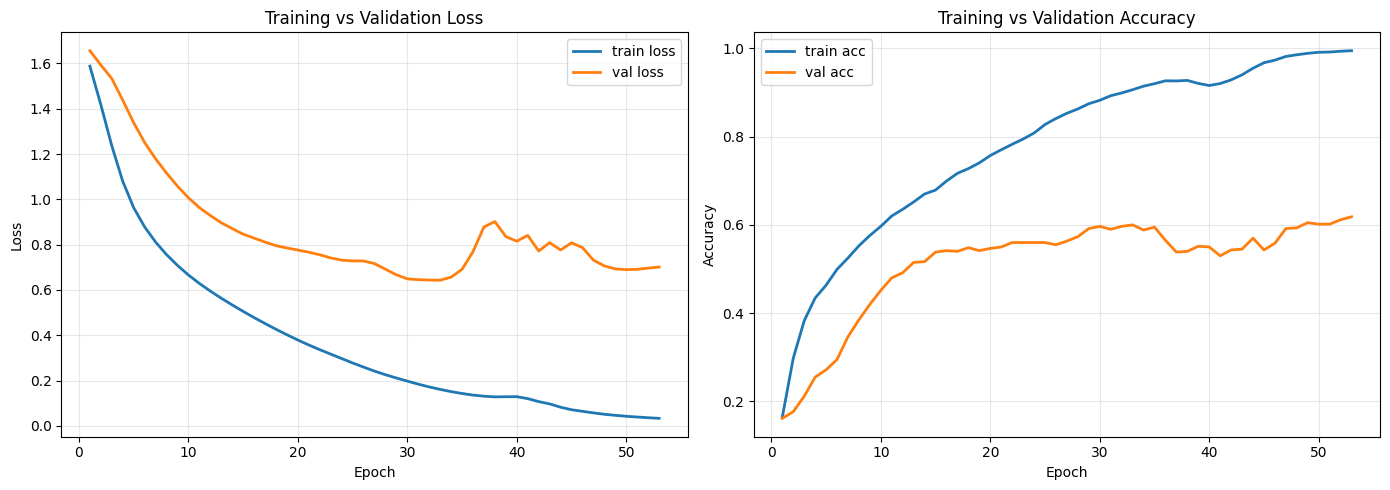

Saved curves to /kaggle/working/results_multibranch_attention_bfrb_bayesian/20261005_131003/multibranch_attention_curves.png
Epochs run: 53
Best val_loss epoch: 33  (val_loss=0.6430)


In [8]:
best_model = search.best_estimator_
save_dir = results_dir / timestamp
save_dir.mkdir(parents=True, exist_ok=True)

# --- pull the history out of the fitted pipeline ---
best_estimator = best_model.named_steps['estimator']
history = best_estimator.get_history_dict()   # returns self.history_

loss      = history.get('loss', [])
val_loss  = history.get('val_loss', [])
acc       = history.get('accuracy', [])
val_acc   = history.get('val_accuracy', [])

has_val = len(val_loss) > 0 and len(val_acc) > 0
epochs_ran = range(1, len(loss) + 1)

# --- two subplots, two lines each ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(epochs_ran, loss, label='train loss', linewidth=2)
if has_val:
    ax.plot(epochs_ran, val_loss, label='val loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.grid(alpha=0.3)
ax.legend()

# ---- Accuracy ----
ax = axes[1]
ax.plot(epochs_ran, acc, label='train acc', linewidth=2)
if has_val:
    ax.plot(epochs_ran, val_acc, label='val acc', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

# save next to the other results (save_dir is defined in your last cell)
curves_path = save_dir / f'{experiment_name}_curves.png'
# plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved curves to {curves_path}')
print(f'Epochs run: {len(loss)}')
if has_val:
    best_epoch = int(np.argmin(val_loss)) + 1
    print(f'Best val_loss epoch: {best_epoch}  (val_loss={min(val_loss):.4f})')

In [9]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

eval_results = evaluate_holdout(
    y_test,
    y_pred,
    target_col=TARGET_COL,
    verbose=True,
)

print('Holdout competition score / macro F1:', eval_results['competition_score'])


FINAL EVALUATION
Binary F1 (non_bfrb vs bfrb): 1.0000
BFRB Gesture Macro F1: 0.6052
COMPETITION SCORE: 0.8026

----------------------------------------
BFRB Gesture Classification Report
----------------------------------------
                          precision    recall  f1-score   support

   Above ear - pull hair       0.63      0.72      0.67        78
      Cheek - pinch skin       0.59      0.53      0.55        78
     Eyebrow - pull hair       0.49      0.51      0.50        78
     Eyelash - pull hair       0.51      0.48      0.49        79
Forehead - pull hairline       0.73      0.62      0.67        79
      Forehead - scratch       0.79      0.76      0.77        79
       Neck - pinch skin       0.55      0.53      0.54        79
          Neck - scratch       0.59      0.70      0.64        79

                accuracy                           0.61       629
               macro avg       0.61      0.61      0.61       629
            weighted avg       0.61      0.

In [10]:
save_dir = results_dir / timestamp
save_dir.mkdir(parents=True, exist_ok=True)
best_estimator = best_model.named_steps['estimator']
best_estimator.model_.save(save_dir / 'best_model.h5')

pd.DataFrame(search.cv_results_).to_csv(
    save_dir / f'{experiment_name}_cv.csv',
    index=False,
)
eval_results['results_df'].to_csv(
    save_dir / f'{experiment_name}_holdout.csv',
    index=False,
)
pd.DataFrame([{
    'target': TARGET_COL,
    'best_score': search.best_score_,
    'best_params': json.dumps(search.best_params_, default=str),
    'holdout_score': eval_results['competition_score'],
}]).to_csv(
    save_dir / f'{experiment_name}_best.csv',
    index=False,
)

with open(save_dir / 'results.json', 'w') as results_file:
    json.dump({
        'target': TARGET_COL,
        'best_score': float(search.best_score_),
        'best_params': search.best_params_,
        'holdout_score': float(eval_results['competition_score']),
        'random_state': random_state,
        'train_sequences': int(X_train['sequence_id'].nunique()),
        'holdout_sequences': int(X_test['sequence_id'].nunique()),
    }, results_file, indent=2, default=str)

print(f'Results saved to {save_dir}')

Results saved to /kaggle/working/results_multibranch_attention_bfrb_bayesian/20261005_131003
